In [1]:
import pandas as pd
import glob

In [2]:
arquivos = sorted(glob.glob(r'C:\Users\paulo\Desktop\pythonAnalise\analise\projeto6\HIST_PAINEL_COVIDBR_05set2025/*.csv'))

df = pd.concat([pd.read_csv(f, sep= ';') for f in arquivos], ignore_index=True)                  

In [3]:
df.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11177059 entries, 0 to 11177058
Data columns (total 17 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   regiao                  object 
 1   estado                  object 
 2   municipio               object 
 3   coduf                   int64  
 4   codmun                  float64
 5   codRegiaoSaude          float64
 6   nomeRegiaoSaude         object 
 7   data                    object 
 8   semanaEpi               int64  
 9   populacaoTCU2019        float64
 10  casosAcumulado          float64
 11  casosNovos              int64  
 12  obitosAcumulado         int64  
 13  obitosNovos             int64  
 14  Recuperadosnovos        float64
 15  emAcompanhamentoNovos   float64
 16  interior/metropolitana  float64
dtypes: float64(7), int64(5), object(5)
memory usage: 4.1 GB




•	A Demanda: Filtre a base para mantermos exclusivamente os dados a nível Estadual.

•	Como fazer: Mantenha as linhas onde estado não é nulo (notna()), mas municipio é nulo (isna()).


In [4]:
df.shape

(11177059, 17)

In [5]:
df = df[df['estado'].notna() & df['municipio'].isna()]

In [6]:
df.shape

(96309, 17)

In [7]:
df.head()

,regiao,estado,municipio,coduf,codmun,codRegiaoSaude,nomeRegiaoSaude,data,semanaEpi,populacaoTCU2019,casosAcumulado,casosNovos,obitosAcumulado,obitosNovos,Recuperadosnovos,emAcompanhamentoNovos,interior/metropolitana
158,Norte,RO,NaN,11,NaN,NaN,NaN,2020-02-25,9,1777225.0,0.0,0,0,0,NaN,NaN,NaN
159,Norte,RO,NaN,11,NaN,NaN,NaN,2020-02-26,9,1777225.0,0.0,0,0,0,NaN,NaN,NaN
160,Norte,RO,NaN,11,NaN,NaN,NaN,2020-02-27,9,1777225.0,0.0,0,0,0,NaN,NaN,NaN
161,Norte,RO,NaN,11,NaN,NaN,NaN,2020-02-28,9,1777225.0,0.0,0,0,0,NaN,NaN,NaN
162,Norte,RO,NaN,11,NaN,NaN,NaN,2020-02-29,9,1777225.0,0.0,0,0,0,NaN,NaN,NaN


•	Tipagem: Converta a coluna data para o formato temporal nativo do Pandas (pd.to_datetime()).

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 96309 entries, 158 to 11160509
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   regiao                  96309 non-null  object 
 1   estado                  96309 non-null  object 
 2   municipio               0 non-null      object 
 3   coduf                   96309 non-null  int64  
 4   codmun                  41769 non-null  float64
 5   codRegiaoSaude          0 non-null      float64
 6   nomeRegiaoSaude         0 non-null      object 
 7   data                    96309 non-null  object 
 8   semanaEpi               96309 non-null  int64  
 9   populacaoTCU2019        54540 non-null  float64
 10  casosAcumulado          96309 non-null  float64
 11  casosNovos              96309 non-null  int64  
 12  obitosAcumulado         96309 non-null  int64  
 13  obitosNovos             96309 non-null  int64  
 14  Recuperadosnovos        0 non-null    

In [9]:
df['data'] = pd.to_datetime(df['data'])

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 96309 entries, 158 to 11160509
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   regiao                  96309 non-null  object        
 1   estado                  96309 non-null  object        
 2   municipio               0 non-null      object        
 3   coduf                   96309 non-null  int64         
 4   codmun                  41769 non-null  float64       
 5   codRegiaoSaude          0 non-null      float64       
 6   nomeRegiaoSaude         0 non-null      object        
 7   data                    96309 non-null  datetime64[ns]
 8   semanaEpi               96309 non-null  int64         
 9   populacaoTCU2019        54540 non-null  float64       
 10  casosAcumulado          96309 non-null  float64       
 11  casosNovos              96309 non-null  int64         
 12  obitosAcumulado         96309 non-null  int64 

In [10]:
df['data'] = df['data'].dt.strftime('%d-%m-%Y')

df.head()

,regiao,estado,municipio,coduf,codmun,codRegiaoSaude,nomeRegiaoSaude,data,semanaEpi,populacaoTCU2019,casosAcumulado,casosNovos,obitosAcumulado,obitosNovos,Recuperadosnovos,emAcompanhamentoNovos,interior/metropolitana
158,Norte,RO,NaN,11,NaN,NaN,NaN,25-02-2020,9,1777225.0,0.0,0,0,0,NaN,NaN,NaN
159,Norte,RO,NaN,11,NaN,NaN,NaN,26-02-2020,9,1777225.0,0.0,0,0,0,NaN,NaN,NaN
160,Norte,RO,NaN,11,NaN,NaN,NaN,27-02-2020,9,1777225.0,0.0,0,0,0,NaN,NaN,NaN
161,Norte,RO,NaN,11,NaN,NaN,NaN,28-02-2020,9,1777225.0,0.0,0,0,0,NaN,NaN,NaN
162,Norte,RO,NaN,11,NaN,NaN,NaN,29-02-2020,9,1777225.0,0.0,0,0,0,NaN,NaN,NaN


In [11]:
df['data'] = pd.to_datetime(df['data'])

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 96309 entries, 158 to 11160509
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   regiao                  96309 non-null  object        
 1   estado                  96309 non-null  object        
 2   municipio               0 non-null      object        
 3   coduf                   96309 non-null  int64         
 4   codmun                  41769 non-null  float64       
 5   codRegiaoSaude          0 non-null      float64       
 6   nomeRegiaoSaude         0 non-null      object        
 7   data                    96309 non-null  datetime64[ns]
 8   semanaEpi               96309 non-null  int64         
 9   populacaoTCU2019        54540 non-null  float64       
 10  casosAcumulado          96309 non-null  float64       
 11  casosNovos              96309 non-null  int64         
 12  obitosAcumulado         96309 non-null  int64 

C:\Users\paulo\AppData\Local\Temp\ipykernel_18920\1828057808.py:1: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['data'] = pd.to_datetime(df['data'])


1.	O Impacto Acumulado: Um gráfico de barras horizontal que mostre o Total de Óbitos Acumulados por Estado.

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns


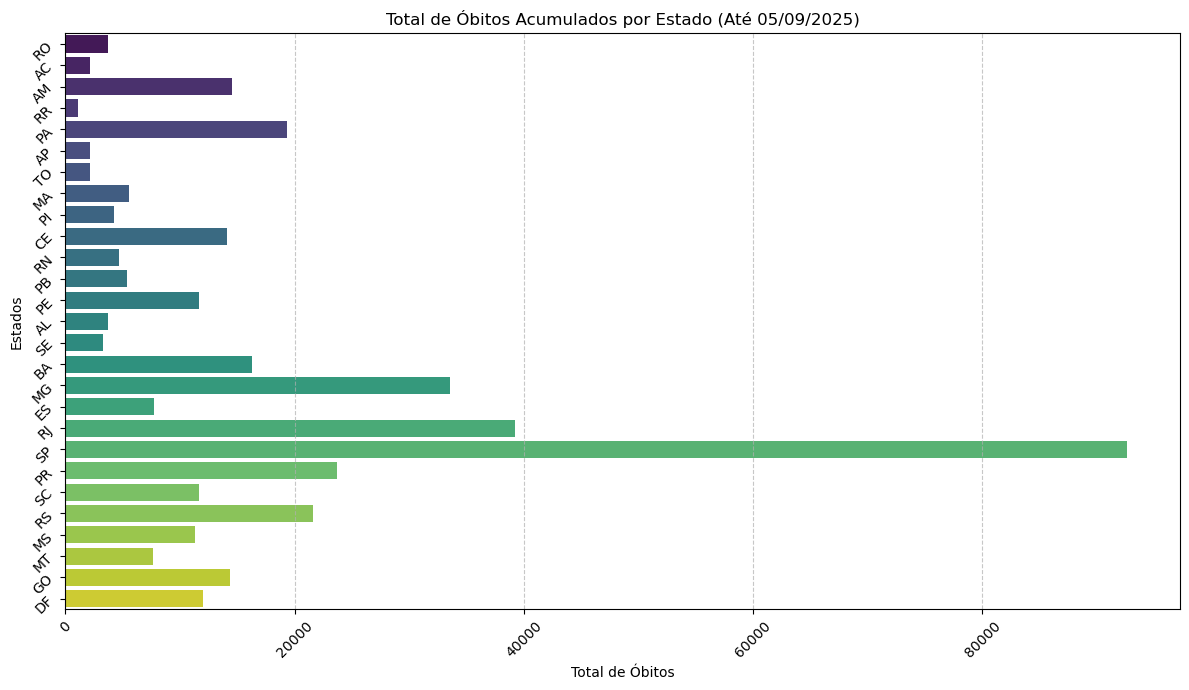

In [13]:
data_maxima = df['data'].max() 
df_ultimo_dia = df[df['data'] == data_maxima] 


plt.figure(figsize=(12, 7))

grafico_totalObitos = sns.barplot(data=df_ultimo_dia, y='estado', x='obitosAcumulado', hue='estado', palette='viridis', errorbar=None)

plt.title(f'Total de Óbitos Acumulados por Estado (Até {data_maxima.strftime("%d/%m/%Y")})')
plt.xlabel('Total de Óbitos')
plt.ylabel('Estados')


plt.xticks(rotation=45) 
plt.yticks(rotation=45)



plt.grid(axis='x', linestyle='--', alpha=0.7)


plt.tight_layout()
plt.show() 

imagem = grafico_totalObitos.get_figure()
imagem.savefig('Grafico_totalObitos.png') 

2.	A Curva Pandémica: Um gráfico de linhas (Lineplot) que mostre a evolução temporal dos Casos Novos (casosNovos) somados diariamente a nível nacional.

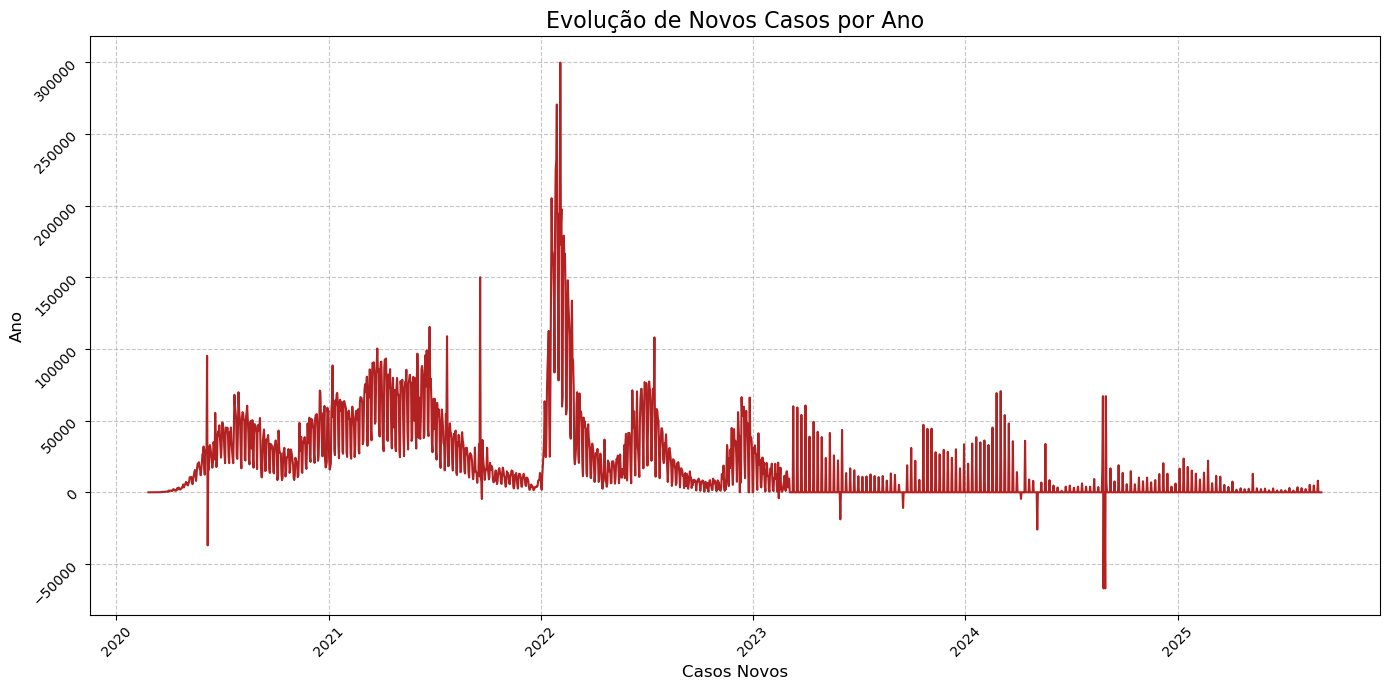

In [14]:
df_brasil_diario = df.groupby('data')['casosNovos'].sum().reset_index()


plt.figure(figsize=(14, 7))

grafico_casosAno = sns.lineplot(data=df_brasil_diario, x='data', y='casosNovos', color='firebrick')

plt.title('Evolução de Novos Casos por Ano', fontsize=16)
plt.xlabel('Casos Novos', fontsize=12)
plt.ylabel('Ano', fontsize=12)


plt.xticks(rotation=45) 
plt.yticks(rotation=45)



plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.grid(axis='y', linestyle='--', alpha=0.7)


plt.tight_layout()
plt.show() 

imagem = grafico_casosAno.get_figure()
imagem.savefig('Grafico_CasosPorAno.png') 


•	A Demanda: Crie uma nova coluna no seu DataFrame chamada Taxa_Mortalidade_100k.

In [15]:
obitos = df['obitosAcumulado']
populacaoTCU = df['populacaoTCU2019']

calculo_proporcao = ((obitos / populacaoTCU) * 100000).round(2)

df['Taxa_Mortalidade_100k'] = calculo_proporcao

In [16]:
df[['obitosAcumulado', 'populacaoTCU2019', 'Taxa_Mortalidade_100k']].sample(10)

,obitosAcumulado,populacaoTCU2019,Taxa_Mortalidade_100k
9813585,23,NaN,NaN
10801610,6592,2298696.0,286.77
118236,0,NaN,NaN
3751803,0,NaN,NaN
4672564,23,NaN,NaN
2679824,0,NaN,NaN
9787755,43189,11377239.0,379.61
3627386,10194,4018127.0,253.70
714914,732,881935.0,83.00
7729599,7334,3337357.0,219.75


•	O Gráfico: Crie um novo gráfico de barras com  a Taxa de Mortalidade. Taxa de Mortalidade: Será que São Paulo ainda está em primeiro lugar quando olhamos de forma proporcional?

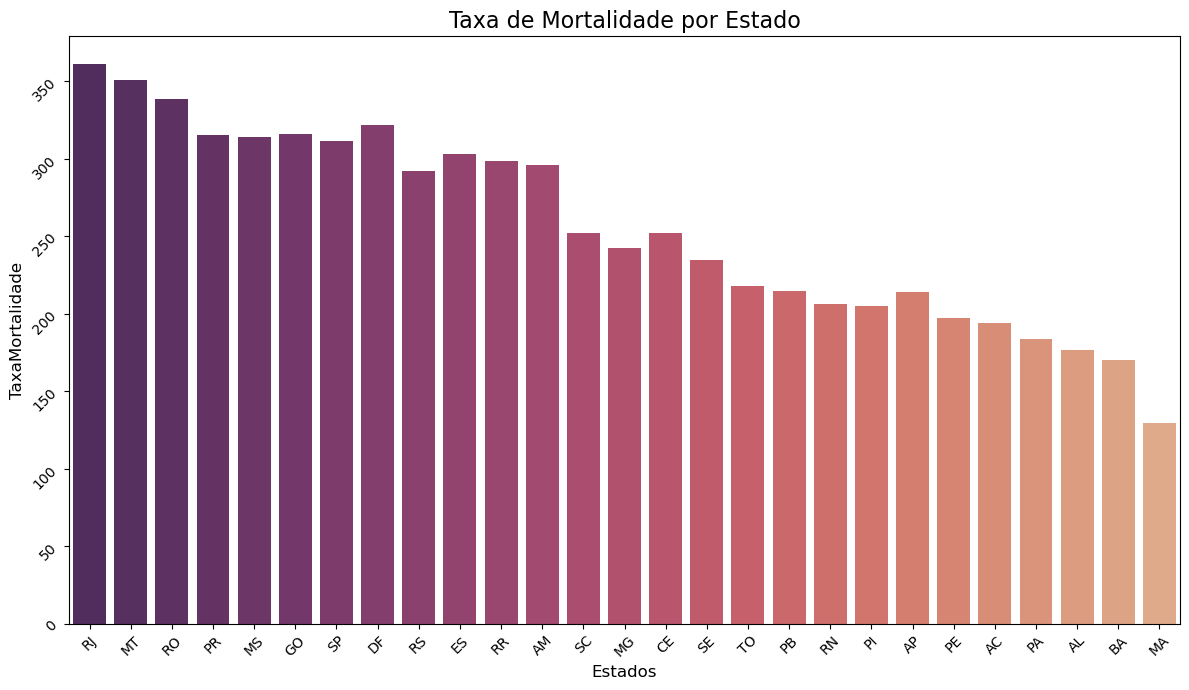

In [17]:
top_5_taxaMortalidade = df.sort_values(by='Taxa_Mortalidade_100k', ascending=False)


plt.figure(figsize=(12, 7))

grafico_taxaMortalidade = sns.barplot(data=top_5_taxaMortalidade, y='Taxa_Mortalidade_100k', 
                                      x='estado',
                                      hue='estado',
                                      palette='flare_r', 
                                      dodge=False,
                                      legend=False,
                                      errorbar=None)

plt.title('Taxa de Mortalidade por Estado', fontsize = 16)
plt.ylabel('TaxaMortalidade', fontsize = 12)
plt.xlabel('Estados', fontsize = 12)

plt.xticks(rotation=45) 
plt.yticks(rotation=45)

plt.tight_layout()
plt.show() 

imagem = grafico_taxaMortalidade.get_figure()
imagem.savefig('grafico_taxaMortalidade.png') 

Extraia o "Ano" e o "Mês" da coluna de data para criar duas novas colunas (Ano e Mes).

In [21]:
df.head()

,regiao,estado,municipio,coduf,codmun,codRegiaoSaude,nomeRegiaoSaude,data,semanaEpi,populacaoTCU2019,casosAcumulado,casosNovos,obitosAcumulado,obitosNovos,Recuperadosnovos,emAcompanhamentoNovos,interior/metropolitana,Taxa_Mortalidade_100k
158,Norte,RO,NaN,11,NaN,NaN,NaN,2020-02-25,9,1777225.0,0.0,0,0,0,NaN,NaN,NaN,0.0
159,Norte,RO,NaN,11,NaN,NaN,NaN,2020-02-26,9,1777225.0,0.0,0,0,0,NaN,NaN,NaN,0.0
160,Norte,RO,NaN,11,NaN,NaN,NaN,2020-02-27,9,1777225.0,0.0,0,0,0,NaN,NaN,NaN,0.0
161,Norte,RO,NaN,11,NaN,NaN,NaN,2020-02-28,9,1777225.0,0.0,0,0,0,NaN,NaN,NaN,0.0
162,Norte,RO,NaN,11,NaN,NaN,NaN,2020-02-29,9,1777225.0,0.0,0,0,0,NaN,NaN,NaN,0.0


In [35]:
df_colunas_diaAno = df

df_colunas_diaAno['ano'] = df_colunas_diaAno['data'].dt.year
df_colunas_diaAno['mes'] = df_colunas_diaAno['data'].dt.month


df_colunas_diaAno[['data', 'ano', 'mes']].head()

,regiao,estado,municipio,coduf,codmun,codRegiaoSaude,nomeRegiaoSaude,data,semanaEpi,populacaoTCU2019,...,casosNovos,obitosAcumulado,obitosNovos,Recuperadosnovos,emAcompanhamentoNovos,interior/metropolitana,Taxa_Mortalidade_100k,ano,mes,maximo_entre_colunas
158,Norte,RO,NaN,11,NaN,NaN,NaN,2020-02-25,9,1777225.0,...,0,0,0,NaN,NaN,NaN,0.0,2020,2,0
159,Norte,RO,NaN,11,NaN,NaN,NaN,2020-02-26,9,1777225.0,...,0,0,0,NaN,NaN,NaN,0.0,2020,2,0
160,Norte,RO,NaN,11,NaN,NaN,NaN,2020-02-27,9,1777225.0,...,0,0,0,NaN,NaN,NaN,0.0,2020,2,0
161,Norte,RO,NaN,11,NaN,NaN,NaN,2020-02-28,9,1777225.0,...,0,0,0,NaN,NaN,NaN,0.0,2020,2,0
162,Norte,RO,NaN,11,NaN,NaN,NaN,2020-02-29,9,1777225.0,...,0,0,0,NaN,NaN,NaN,0.0,2020,2,0


Crie uma tabela dinâmica ou um agrupamento (groupby) que mostre o total de obitosNovos e casosNovos somados por Região (regiao) e por Ano.

In [54]:

df_colunas_diaAno['maximo_entre_regiao'] = df_colunas_diaAno[['obitosNovos', 'casosNovos']].max(axis=1)


resultado = df_colunas_diaAno.groupby(['regiao', 'ano'])['maximo_entre_regiao'].sum().reset_index()

resultado

,regiao,ano,maximo_entre_regiao
0,Centro-Oeste,2020,875400
1,Centro-Oeste,2021,1528110
2,Centro-Oeste,2022,1763163
3,Centro-Oeste,2023,280016
4,Centro-Oeste,2024,157069
5,Centro-Oeste,2025,46873
6,Nordeste,2020,1963185
7,Nordeste,2021,3089070
8,Nordeste,2022,2296934
9,Nordeste,2023,297493


In [58]:
resultado.to_csv("dossie_covid_regiao_anual.csv", sep= ';',index=False)

In [59]:
df.to_csv("tabelasUnidas.csv", sep= ';',index=False)